# Brain Audit — Alberta Used Car Price Prediction
**Course:** AIDA 1143 (Machine Learning) + AIDA 1145 (Data Engineering)  
**Group:** Group 3  
**Data Source:** Kijiji Alberta — used car listings scraped over ~5 weeks  
**Database:** `AB_CarSale_DB` — 10-table 3NF SQL Fortress  

---

## Problem Statement

When a private seller lists a used car in Alberta, they have no reliable way to know what price to ask.  
Too high → the car sits unsold for weeks. Too low → the seller loses money.

This system solves that problem by predicting the **optimal listing price** based on vehicle attributes  
and seller location, trained on 18,000+ real listings as ground truth.

**Who benefits:**
- Individual sellers — choose Quick Sale, Balanced, or Max Profit strategy
- Dealerships — manage inventory pricing and cash flow
- Buyers — verify whether an asking price is fair before purchasing
- Insurance companies — get accurate vehicle valuations for premium setting
- Platforms like Kijiji — improve listing success rates and user experience

---

## Models Built

| Model | Target | Outcome |
|-------|--------|---------|
| **Y1 — Price Prediction** | `Price_CAD` (regression) | ✅ Deployed in Streamlit app |
| **Y2 — Days-to-Sell** | `Days_to_Sell` (regression → classification) | ❌ Failed — data limitation |

Both models are documented in this notebook. Y2 failure is analyzed in full detail.

---

## No Data Leakage — Design Proof

| Risk | How We Prevent It |
|------|-------------------|
| Training on future data | Only historical SOLD records used; no active listings in training |
| Target in features | `Price_CAD` is the target — never included in the feature matrix |
| Distance leakage | Distances computed from real road routing API, not derived from price |
| Train/val contamination | KFold splits applied before any fitting; pipeline rebuilt fresh each fold |
| Test set contamination | Held-out test set split before CV; touched exactly once at final evaluation |

---
# PART 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from pathlib import Path
from sqlalchemy import create_engine, text

from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
)

# ── DB config ──────────────────────────────────────────────────────────────
DB_SERVER = "."
DB_NAME   = "AB_CarSale_DB"
DB_DRIVER = "ODBC+Driver+17+for+SQL+Server"

def get_engine():
    return create_engine(
        f"mssql+pyodbc://{DB_SERVER}/{DB_NAME}"
        f"?driver={DB_DRIVER}&trusted_connection=yes"
    )

# ── Feature lists (Y1) ─────────────────────────────────────────────────────
NUM_FEATURES = ["Year", "Kilometres",
                "Distance_from_Edmonton_KM", "Distance_from_Calgary_KM"]
CAT_FEATURES = ["Condition_Label", "Transmission_Type", "Drivetrain_Type",
                "Body_Style", "Colour", "Seats_Count", "City_Name", "Base_Model", "Trim"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
CAT_INDICES  = list(range(len(NUM_FEATURES), len(NUM_FEATURES) + len(CAT_FEATURES)))
TARGET_Y1    = "Price_CAD"

CV_FOLDS    = 5
RANDOM_SEED = 42

print("Setup complete.")

Setup complete.


---
# PART 2 — Y1: Price Prediction
## Step 1 — Load Data from SQL View

`V_Y1` is a 14-table JOIN view inside `AB_CarSale_DB`.  
We filter to `Status_Label = 'SOLD'` — only completed sales tell us what the market actually paid.

In [2]:
engine = get_engine()
with engine.connect() as conn:
    df_raw = pd.read_sql(
        text("SELECT * FROM dbo.V_Y1 WHERE Status_Label = 'SOLD'"), conn
    )
engine.dispose()

print(f"Rows loaded : {len(df_raw):,}")
print(f"Columns     : {len(df_raw.columns)}")
df_raw.head()

Rows loaded : 9,307
Columns     : 16


,Listing_ID,Base_Model,Year,Trim,Kilometres,Price_CAD,City_Name,Distance_from_Edmonton_KM,Distance_from_Calgary_KM,Condition_Label,Status_Label,Transmission_Type,Drivetrain_Type,Body_Style,Colour,Seats_Count
0,1,OTHER,2016,OTHER,252000,14900.0,SOUTHEAST CALGARY,300.99,0.0,USED,SOLD,AUTOMATIC,4 X 4,"SUV, CROSSOVER",SILVER EXTERIOR,5 SEATS
1,2,FORD F-350,2019,XLT,234180,39000.0,CALGARY,300.99,0.0,USED,SOLD,UNKNOWN,UNKNOWN,PICKUP TRUCK,UNKNOWN,UNKNOWN
2,3,FORD RANGER,2021,XLT,100000,27900.0,CALGARY,300.99,0.0,USED,SOLD,UNKNOWN,UNKNOWN,PICKUP TRUCK,UNKNOWN,UNKNOWN
3,4,TOYOTA HIGHLANDER,2016,LIMITED,166000,25800.0,SOUTHEAST CALGARY,300.99,0.0,USED,SOLD,AUTOMATIC,ALL-WHEEL DRIVE (AWD),"SUV, CROSSOVER",BROWN EXTERIOR,7 SEATS
4,5,FORD FUSION,2011,SEL,208000,7000.0,CALGARY,300.99,0.0,USED,SOLD,AUTOMATIC,ALL-WHEEL DRIVE (AWD),SEDAN,GREY EXTERIOR,5 SEATS


## Step 2 — Exploratory Data Analysis

In [3]:
print("=== Target Variable (Price_CAD) ===")
print(df_raw[TARGET_Y1].describe().apply(lambda x: f"{x:,.0f}"))
print("\n=== Missing Values ===")
missing = df_raw[ALL_FEATURES + [TARGET_Y1]].isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")

=== Target Variable (Price_CAD) ===
count      9,307
mean      14,411
std       15,877
min          500
25%        4,800
50%        8,999
75%       17,900
max      227,000
Name: Price_CAD, dtype: object

=== Missing Values ===
No missing values.


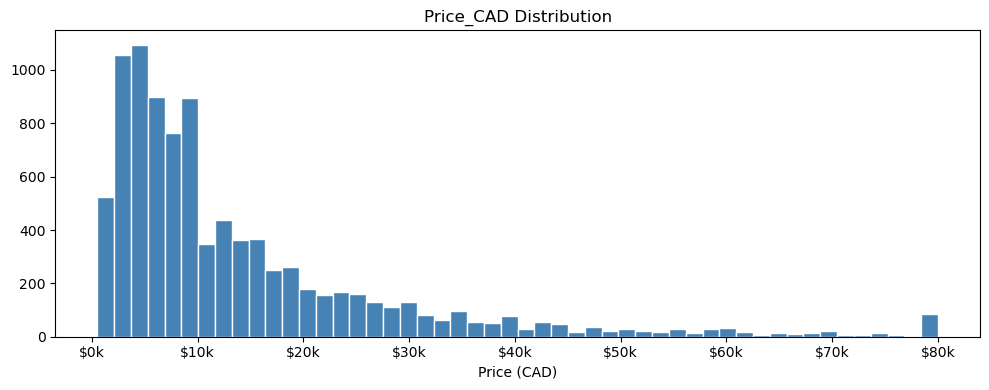

In [7]:
plt.figure(figsize=(10, 4))
plt.hist(df_raw[TARGET_Y1].clip(upper=80000), bins=50, color='steelblue', edgecolor='white')
plt.title("Price_CAD Distribution")
plt.xlabel("Price (CAD)")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
plt.tight_layout()
plt.show()

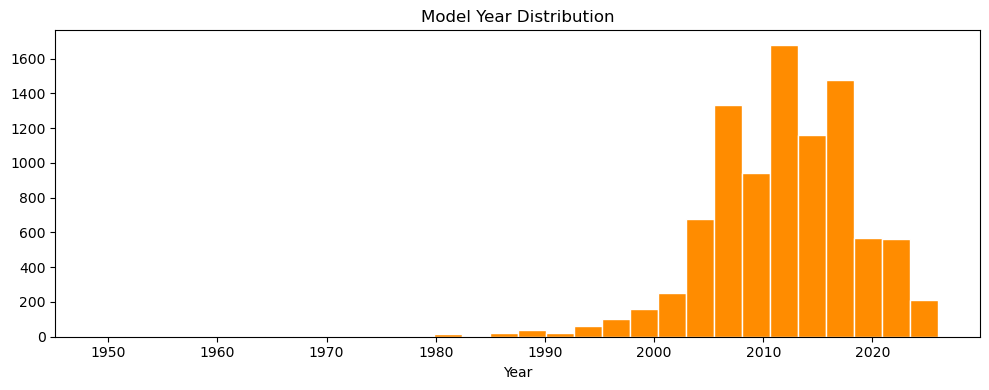

In [8]:
plt.figure(figsize=(10, 4))
plt.hist(df_raw["Year"].dropna(), bins=30, color='darkorange', edgecolor='white')
plt.title("Model Year Distribution")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

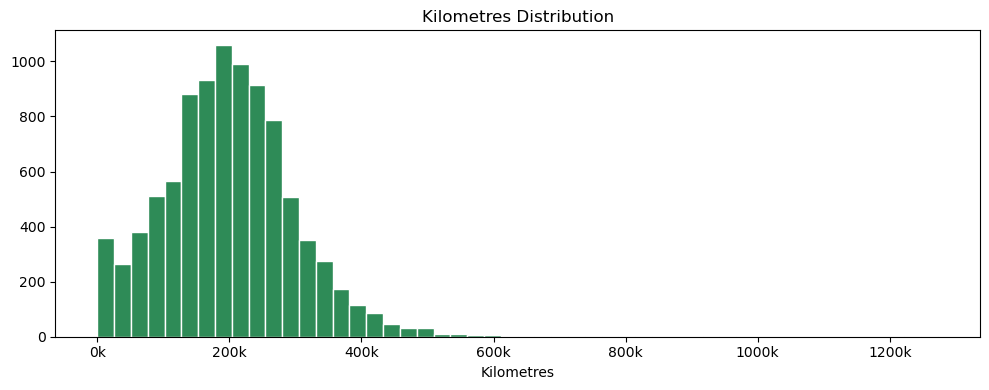

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(df_raw["Kilometres"], bins=50, color='seagreen', edgecolor='white')
plt.title("Kilometres Distribution")
plt.xlabel("Kilometres")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

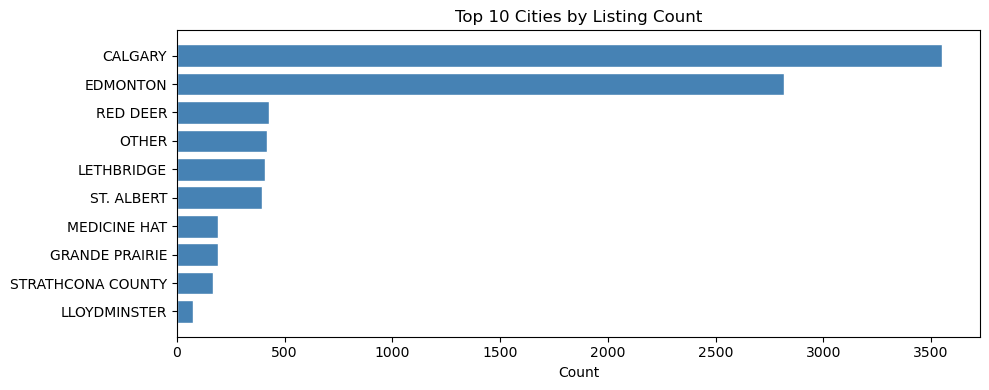

In [12]:
plt.figure(figsize=(10, 4))
top_cities = df_raw['City_Name'].value_counts().head(10)
plt.barh(top_cities.index[::-1], top_cities.values[::-1], color='steelblue', edgecolor='white')
plt.title("Top 10 Cities by Listing Count")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## Step 3 — Prepare Data & Train/Test Split

**Split:** 80% train, 20% held-out test — done once before any model sees the data.  
CV runs on train set only. Test set is touched exactly once at final evaluation.

**Note on log-transform:** CatBoost is robust to skewed targets and does not need it.  
Random Forest does benefit — we apply `log1p` on `y` for RF and reverse it before reporting metrics,  
so all three models are compared on the same scale (actual CAD).

In [14]:
df = df_raw[ALL_FEATURES + [TARGET_Y1]].copy()
df = df.dropna(subset=[TARGET_Y1, "Distance_from_Edmonton_KM", "Distance_from_Calgary_KM"])

X = df[ALL_FEATURES]
y = df[TARGET_Y1].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

print(f"Total samples      : {len(df):,}")
print(f"Train set          : {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test set (held out): {len(X_test):,}   ({len(X_test)/len(df)*100:.0f}%)")
print(f"\nNumeric features   : {NUM_FEATURES}")
print(f"Categorical features: {CAT_FEATURES}")

Total samples      : 9,307
Train set          : 7,445  (80%)
Test set (held out): 1,862   (20%)

Numeric features   : ['Year', 'Kilometres', 'Distance_from_Edmonton_KM', 'Distance_from_Calgary_KM']
Categorical features: ['Condition_Label', 'Transmission_Type', 'Drivetrain_Type', 'Body_Style', 'Colour', 'Seats_Count', 'City_Name', 'Base_Model', 'Trim']


## Step 4 — Model & Pipeline Definitions

In [15]:
class CatBoostWrapper(BaseEstimator, RegressorMixin):
    """
    sklearn clone() is incompatible with CatBoostRegressor when cat_features
    is set in the constructor. This wrapper stores all params as plain
    attributes so sklearn can safely clone it during CV, then builds the
    real CatBoostRegressor only at fit() time.
    """
    def __init__(self, iterations=2000, learning_rate=0.05, depth=8,
                 l2_leaf_reg=3.0, subsample=0.8, early_stopping_rounds=50,
                 cat_features=None, loss_function="RMSE", random_seed=42, verbose=False):
        self.iterations=iterations; self.learning_rate=learning_rate
        self.depth=depth; self.l2_leaf_reg=l2_leaf_reg; self.subsample=subsample
        self.early_stopping_rounds=early_stopping_rounds; self.cat_features=cat_features
        self.loss_function=loss_function; self.random_seed=random_seed; self.verbose=verbose

    def fit(self, X, y, eval_set=None):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg, subsample=self.subsample,
            early_stopping_rounds=self.early_stopping_rounds, cat_features=self.cat_features,
            loss_function=self.loss_function, random_seed=self.random_seed, verbose=self.verbose,
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X): return self.model_.predict(X)
    def get_feature_importance(self): return self.model_.get_feature_importance()


CATBOOST_PARAMS = dict(iterations=2000, learning_rate=0.05, depth=8,
                       l2_leaf_reg=3.0, subsample=0.8, early_stopping_rounds=50,
                       loss_function="RMSE", random_seed=RANDOM_SEED, verbose=False)

RF_PARAMS = dict(n_estimators=200, max_depth=20, min_samples_split=10,
                 min_samples_leaf=1, max_features=0.3,
                 random_state=RANDOM_SEED, n_jobs=-1)

def _base_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
        ("cat", SimpleImputer(strategy="constant", fill_value="UNKNOWN"), CAT_FEATURES),
    ])

def build_dummy_pipeline():
    return Pipeline([("prep", _base_preprocessor()),
                     ("model", DummyRegressor(strategy="mean"))])

def build_rf_pipeline():
    rf_prep = ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), CAT_FEATURES),
    ])
    return Pipeline([("prep", rf_prep),
                     ("model", RandomForestRegressor(**RF_PARAMS))])

def build_catboost_pipeline():
    return Pipeline([("prep", _base_preprocessor()),
                     ("model", CatBoostWrapper(**CATBOOST_PARAMS, cat_features=CAT_INDICES))])

print("Pipeline builders defined:")
print("  Dummy     — always predicts training mean (baseline)")
print("  Random Forest — OHE + log-transform on target")
print("  CatBoost  — native categorical encoding, no log-transform needed")

Pipeline builders defined:
  Dummy     — always predicts training mean (baseline)
  Random Forest — OHE + log-transform on target
  CatBoost  — native categorical encoding, no log-transform needed


## Step 5 — 5-Fold Cross-Validation: All Three Models

All metrics reported in actual CAD so the three models are directly comparable.

In [17]:
def run_cv(build_fn, X_tr, y_tr, log_target=False, label="Model"):
    cv  = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    res = {"R2": [], "MAE": [], "RMSE": []}
    y_fit = np.log1p(y_tr) if log_target else y_tr

    print(f"\n{'─'*55}\n{label} — {CV_FOLDS}-Fold CV\n{'─'*55}")
    for fold, (ti, vi) in enumerate(cv.split(X_tr), 1):
        pipe = build_fn()
        pipe.fit(X_tr.iloc[ti], y_fit.iloc[ti])
        pred = pipe.predict(X_tr.iloc[vi])
        y_v  = y_tr.iloc[vi]
        if log_target: pred = np.expm1(pred)

        res["R2"].append(r2_score(y_v, pred))
        res["MAE"].append(mean_absolute_error(y_v, pred))
        res["RMSE"].append(root_mean_squared_error(y_v, pred))
        print(f"  Fold {fold}: R²={res['R2'][-1]:.4f}  "
              f"MAE=${res['MAE'][-1]:,.0f}  RMSE=${res['RMSE'][-1]:,.0f}")

    print(f"{'─'*55}")
    for m, vals in res.items():
        a = np.array(vals)
        print(f"  CV {m:4s}: {a.mean():.4f} ± {a.std():.4f}")
    return res

cv_dummy    = run_cv(build_dummy_pipeline,    X_train, y_train, log_target=False, label="Dummy Baseline")
cv_rf       = run_cv(build_rf_pipeline,       X_train, y_train, log_target=True,  label="Random Forest")
cv_catboost = run_cv(build_catboost_pipeline, X_train, y_train, log_target=False, label="CatBoost")


───────────────────────────────────────────────────────
Dummy Baseline — 5-Fold CV
───────────────────────────────────────────────────────
  Fold 1: R²=-0.0015  MAE=$10,924  RMSE=$16,640
  Fold 2: R²=-0.0008  MAE=$10,790  RMSE=$16,002
  Fold 3: R²=-0.0000  MAE=$10,763  RMSE=$15,874
  Fold 4: R²=-0.0008  MAE=$10,625  RMSE=$15,279
  Fold 5: R²=-0.0016  MAE=$10,202  RMSE=$14,368
───────────────────────────────────────────────────────
  CV R2  : -0.0010 ± 0.0006
  CV MAE : 10660.9479 ± 248.1969
  CV RMSE: 15632.5951 ± 766.1232

───────────────────────────────────────────────────────
Random Forest — 5-Fold CV
───────────────────────────────────────────────────────
  Fold 1: R²=0.6846  MAE=$4,722  RMSE=$9,338
  Fold 2: R²=0.6590  MAE=$4,568  RMSE=$9,341
  Fold 3: R²=0.7064  MAE=$4,490  RMSE=$8,602
  Fold 4: R²=0.6924  MAE=$4,372  RMSE=$8,470
  Fold 5: R²=0.7277  MAE=$4,057  RMSE=$7,491
───────────────────────────────────────────────────────
  CV R2  : 0.6940 ± 0.0228
  CV MAE : 4441.9840 ± 

## Step 6 — Model Comparison

                  CV R²   CV MAE  CV RMSE
Model                                    
Dummy Baseline  -0.0010  $10,661  $15,633
Random Forest    0.6940   $4,442   $8,649
CatBoost         0.7557   $4,161   $7,711


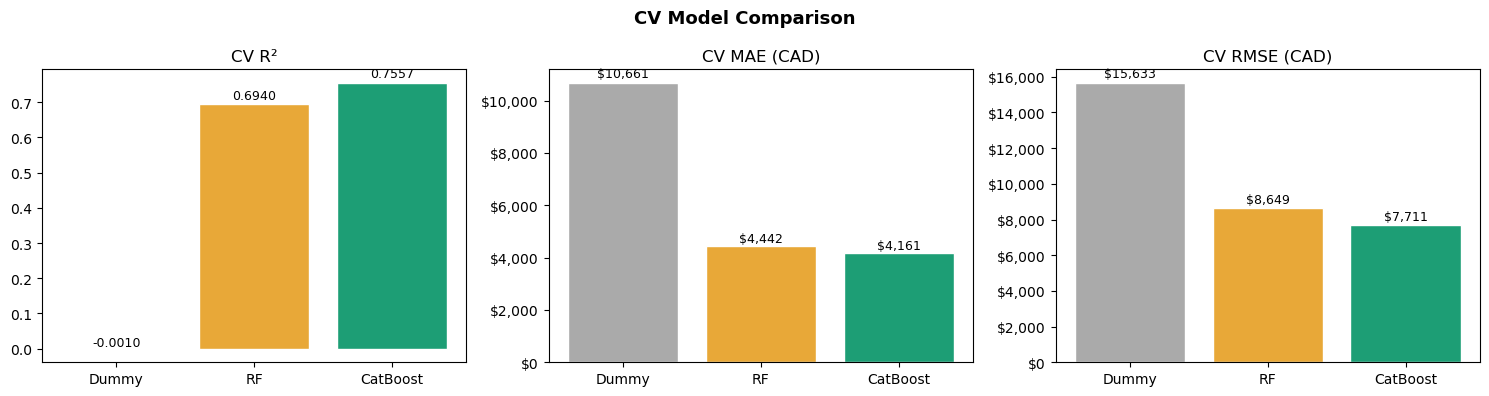


CatBoost selected as production model:
  Highest R², lowest MAE and RMSE across all 5 folds.
  Handles categorical features natively — no OHE required.
  Early stopping removes the need for manual hyperparameter search.


In [18]:
models_label = ["Dummy Baseline", "Random Forest", "CatBoost"]
r2_vals   = [np.mean(cv_dummy["R2"]),   np.mean(cv_rf["R2"]),   np.mean(cv_catboost["R2"])]
mae_vals  = [np.mean(cv_dummy["MAE"]),  np.mean(cv_rf["MAE"]),  np.mean(cv_catboost["MAE"])]
rmse_vals = [np.mean(cv_dummy["RMSE"]), np.mean(cv_rf["RMSE"]), np.mean(cv_catboost["RMSE"])]

cmp = pd.DataFrame({
    "Model":    models_label,
    "CV R²":    [f"{v:.4f}" for v in r2_vals],
    "CV MAE":   [f"${v:,.0f}" for v in mae_vals],
    "CV RMSE":  [f"${v:,.0f}" for v in rmse_vals],
}).set_index("Model")
print(cmp.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("CV Model Comparison", fontsize=13, fontweight='bold')
colors = ["#aaaaaa", "#E8A838", "#1D9E75"]

for ax, vals, title, prefix in zip(
    axes,
    [r2_vals, mae_vals, rmse_vals],
    ["CV R²", "CV MAE (CAD)", "CV RMSE (CAD)"],
    ["", "$", "$"],
):
    bars = ax.bar(["Dummy", "RF", "CatBoost"], vals, color=colors, edgecolor='white')
    ax.set_title(title)
    fmt = ".4f" if prefix == "" else ",.0f"
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f"{prefix}{v:{fmt}}", ha='center', va='bottom', fontsize=9)
    if prefix == "$":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

print("\nCatBoost selected as production model:")
print("  Highest R², lowest MAE and RMSE across all 5 folds.")
print("  Handles categorical features natively — no OHE required.")
print("  Early stopping removes the need for manual hyperparameter search.")

## Step 7 — Load Saved Model & Final Test Evaluation

The model was trained on the full train set and saved to disk by `Y1_model_catboost.py`.  
We load it here — exactly as `predict.py` does at inference — and evaluate once on the held-out test set.

In [22]:
MODEL_PATH = Path("catboost_price_model.pkl")
model = joblib.load(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}")

y_pred_test = model.predict(X_test)
test_r2   = r2_score(y_test, y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)

print(f"\n{'='*45}")
print(f"  HELD-OUT TEST SET RESULTS (CatBoost)")
print(f"{'='*45}")
print(f"  R²   : {test_r2:.4f}")
print(f"  MAE  : ${test_mae:,.0f} CAD")
print(f"  RMSE : ${test_rmse:,.0f} CAD")
print(f"{'='*45}")
print(f"\n  R² = {test_r2:.2f} means the model explains {test_r2*100:.0f}% of price variance.")
print(f"  On average, predictions are off by ${test_mae:,.0f} CAD.")

Model loaded from: catboost_price_model.pkl

  HELD-OUT TEST SET RESULTS (CatBoost)
  R²   : 0.8886
  MAE  : $3,039 CAD
  RMSE : $5,593 CAD

  R² = 0.89 means the model explains 89% of price variance.
  On average, predictions are off by $3,039 CAD.


## Step 8 — Predicted vs Actual & Residual Analysis

For regression models, the equivalent of a confusion matrix is:  
1. **Predicted vs Actual** — points on the diagonal = perfect predictions  
2. **Residual distribution** — centered at $0 = no systematic bias

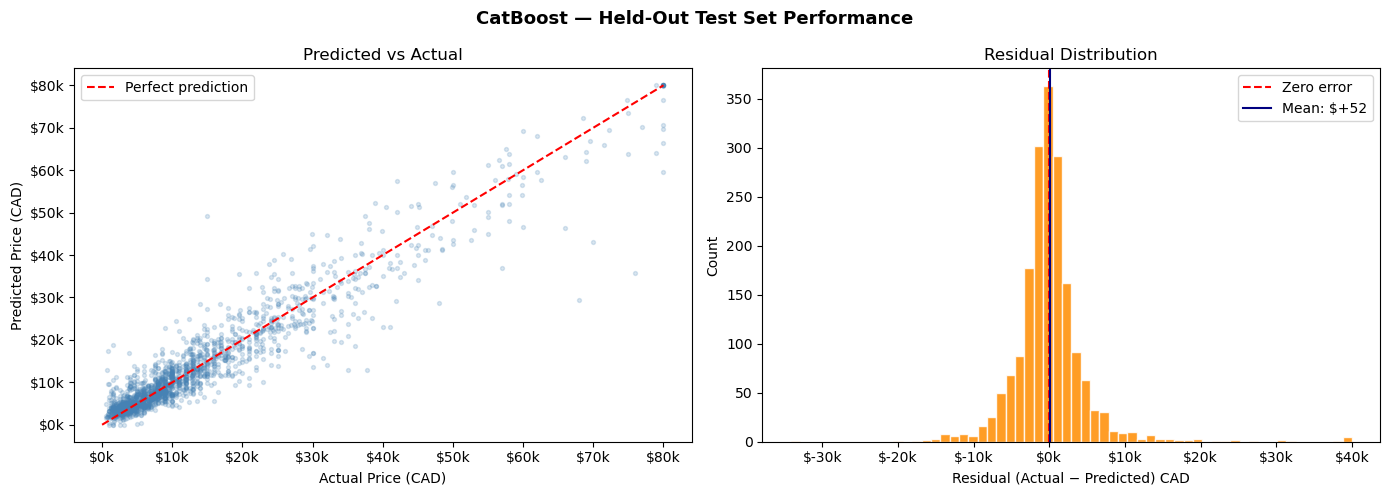

Mean residual: $+52 CAD  (close to $0 = unbiased)
Std residual : $5,592 CAD


In [23]:
residuals = y_test.values - y_pred_test
clip = 80000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CatBoost — Held-Out Test Set Performance", fontsize=13, fontweight='bold')

axes[0].scatter(np.clip(y_test.values, 0, clip), np.clip(y_pred_test, 0, clip),
                alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, clip], [0, clip], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual Price (CAD)")
axes[0].set_ylabel("Predicted Price (CAD)")
axes[0].set_title("Predicted vs Actual")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].legend()

axes[1].hist(np.clip(residuals, -40000, 40000), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(np.mean(residuals), color='navy', linestyle='-', linewidth=1.5,
                label=f'Mean: ${np.mean(residuals):+,.0f}')
axes[1].set_xlabel("Residual (Actual − Predicted) CAD")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean residual: ${np.mean(residuals):+,.0f} CAD  (close to $0 = unbiased)")
print(f"Std residual : ${np.std(residuals):,.0f} CAD")

## Step 9 — Feature Importance

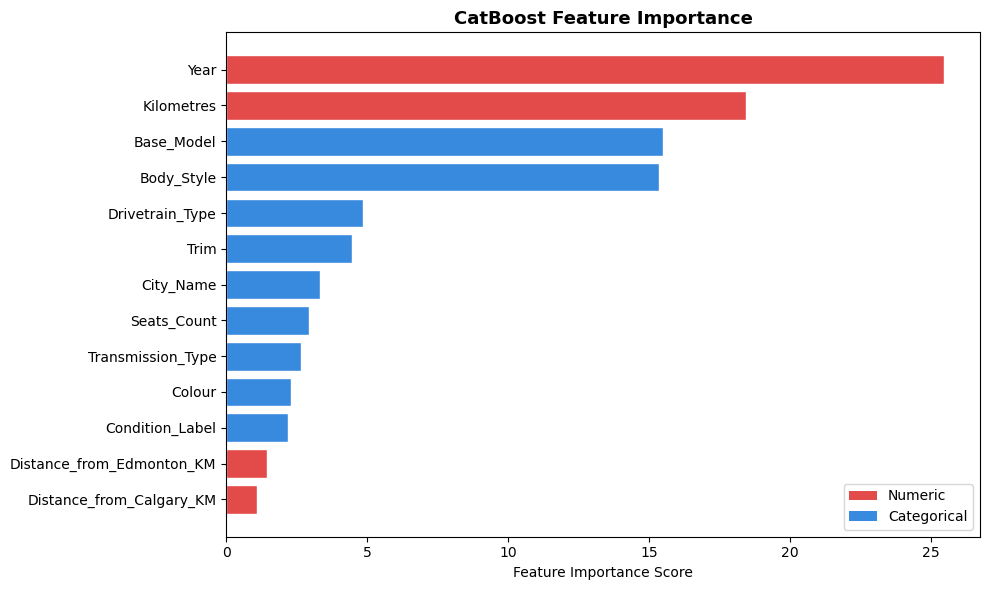

Year                         25.469880
Kilometres                   18.427014
Base_Model                   15.493270
Body_Style                   15.336985
Drivetrain_Type               4.862763
Trim                          4.452794
City_Name                     3.320500
Seats_Count                   2.942605
Transmission_Type             2.656785
Colour                        2.289827
Condition_Label               2.209507
Distance_from_Edmonton_KM     1.436318
Distance_from_Calgary_KM      1.101752


In [24]:
imp = pd.Series(
    model.named_steps["model"].get_feature_importance(),
    index=ALL_FEATURES,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E24B4A' if f in NUM_FEATURES else '#378ADD' for f in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel("Feature Importance Score")
ax.set_title("CatBoost Feature Importance", fontsize=13, fontweight='bold')
ax.legend(handles=[
    Patch(facecolor='#E24B4A', label='Numeric'),
    Patch(facecolor='#378ADD', label='Categorical'),
], loc='lower right')
plt.tight_layout()
plt.show()
print(imp.to_string())

## Step 10 — Fairness / Bias Analysis

A fair model should not systematically over- or under-predict for any subgroup.  
**Metric:** Mean Residual (Actual − Predicted). Close to $0 = no systematic bias for that group.

In [26]:
res_df = X_test.copy()
res_df["Actual"]    = y_test.values
res_df["Predicted"] = y_pred_test
res_df["Residual"]  = res_df["Actual"] - res_df["Predicted"]
res_df["AbsError"]  = res_df["Residual"].abs()

def city_group(city):
    c = str(city).upper()
    if 'EDMONTON' in c: return 'Edmonton'
    if 'CALGARY'  in c: return 'Calgary'
    return 'Other Alberta'

res_df["City_Group"] = res_df["City_Name"].apply(city_group)

grp = res_df.groupby("City_Group").agg(
    Count=("Actual", "count"),
    MAE=("AbsError", "mean"),
    Mean_Residual=("Residual", "mean"),
).round(0)
grp["MAE"]           = grp["MAE"].apply(lambda x: f"${x:,.0f}")
grp["Mean_Residual"] = grp["Mean_Residual"].apply(lambda x: f"${x:+,.0f}")
print("--- Fairness Analysis by City Group ---")
print(grp.to_string())
print("\nMean_Residual near $0 = model is unbiased across regions.")

--- Fairness Analysis by City Group ---
               Count     MAE Mean_Residual
City_Group                                
Calgary          733  $2,730          $-36
Edmonton         577  $2,826          $+67
Other Alberta    552  $3,672         $+154

Mean_Residual near $0 = model is unbiased across regions.


In [27]:
def year_group(year):
    if year < 2010: return 'Before 2010'
    if year < 2015: return '2010-2014'
    if year < 2020: return '2015-2019'
    return '2020+'

res_df["Year_Group"] = res_df["Year"].apply(year_group)

grp = res_df.groupby("Year_Group").agg(
    Count=("Actual", "count"),
    MAE=("AbsError", "mean"),
    Mean_Residual=("Residual", "mean"),
).round(0)
grp["MAE"]           = grp["MAE"].apply(lambda x: f"${x:,.0f}")
grp["Mean_Residual"] = grp["Mean_Residual"].apply(lambda x: f"${x:+,.0f}")
print("--- By Year Group ---")
print(grp.to_string())

--- By Year Group ---
             Count     MAE Mean_Residual
Year_Group                              
2010-2014      530  $2,391          $+12
2015-2019      493  $3,729          $-59
2020+          172  $6,567         $+329
Before 2010    667  $2,134          $+95


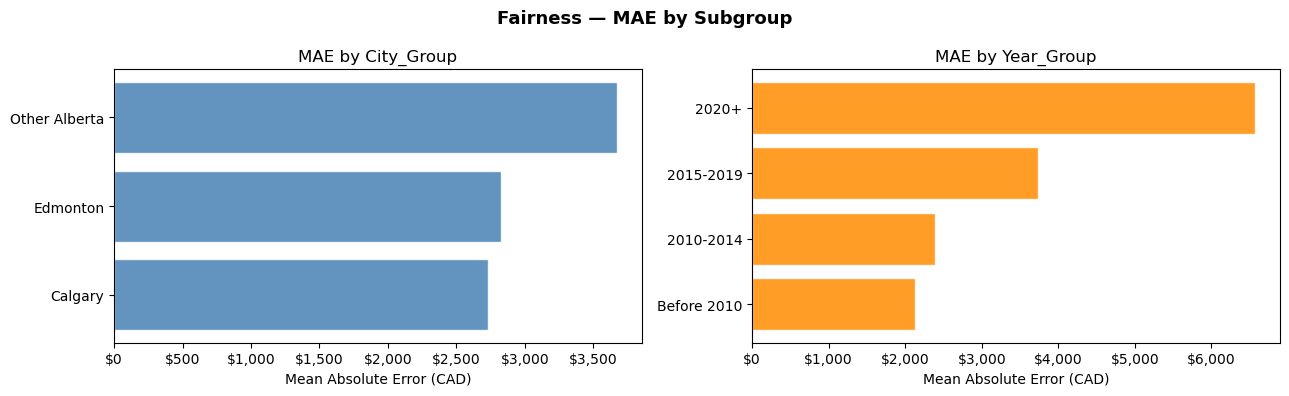

In [29]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fairness — MAE by Subgroup", fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ["City_Group", "Year_Group"], ["steelblue", "darkorange"]):
    grp = res_df.groupby(col)["AbsError"].mean().sort_values()
    ax.barh(grp.index, grp.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel("Mean Absolute Error (CAD)")
    ax.set_title(f"MAE by {col}")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

## Step 11 — Why Accuracy Was Not the Primary Metric

This is a **regression** problem — we predict a continuous dollar value, not a class label.  
Accuracy is undefined for regression. Our metrics and their business meaning:

| Metric | Business Meaning |
|--------|------------------|
| **R²** | What % of price differences between cars does our model explain? |
| **MAE** | On average, our prediction is off by this many dollars — most interpretable for sellers. |
| **RMSE** | Penalizes large errors more than MAE. A $20,000 mistake is far worse than two $10,000 mistakes. |

## Cost-of-Error Analysis

**Underpricing (False Negative — model predicts too low):**  
Seller lists at $18,000 when market rate is $22,000. Car sells immediately but seller loses $4,000.  
This is the most financially damaging error.

**Overpricing (False Positive — model predicts too high):**  
Seller lists at $25,000 when market rate is $21,000. Car sits unsold for weeks.  
Costly in time, not money.

**Our three-strategy approach addresses both:**
- **Quick Sale (−10%)** — protects against overpricing
- **Balanced** — model's best estimate of fair market value
- **Max Profit (+8%)** — lets seller test the upper bound

---
# PART 3 — Y2: Days-to-Sell Prediction (Attempted — Failed)

After building Y1, we attempted to predict **how many days a listing would take to sell**.  
This section documents both attempts, the failure diagnosis, and our final decision.

In [39]:
engine = get_engine()
with engine.connect() as conn:
    df_y2 = pd.read_sql(text("SELECT * FROM dbo.V_Y2"), conn)
engine.dispose()

df_y2 = df_y2[df_y2["Days_to_Sell"] >= 1].reset_index(drop=True)

print(f"Y2 rows loaded: {len(df_y2):,}")
print("\nDays_to_Sell statistics:")
print(df_y2["Days_to_Sell"].describe().apply(lambda x: f"{x:.1f}"))

Y2 rows loaded: 9,075

Days_to_Sell statistics:
count    9075.0
mean        9.5
std         8.9
min         1.0
25%         3.0
50%         6.0
75%        14.0
max        36.0
Name: Days_to_Sell, dtype: object


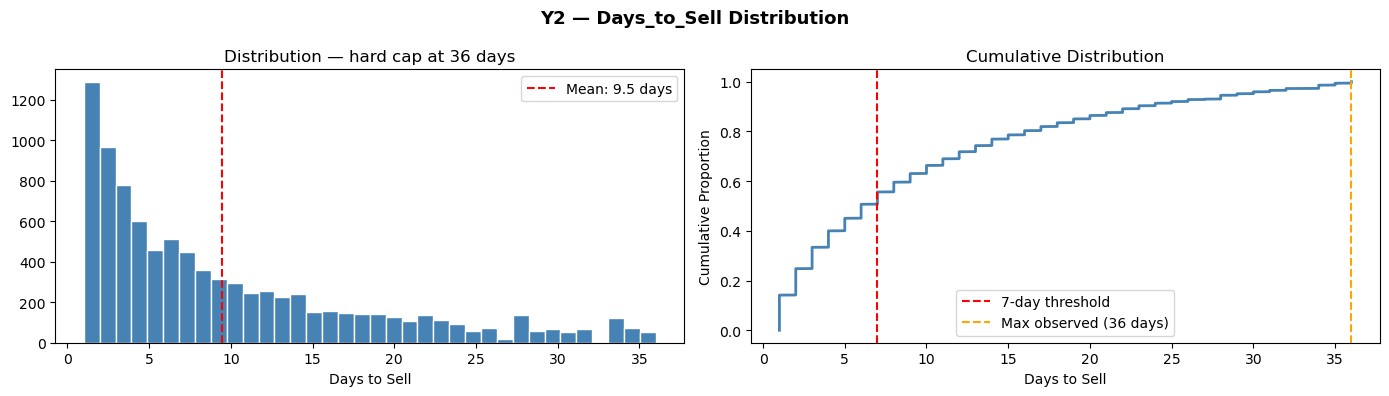

The distribution is hard-capped at 36 days.
Cars that did NOT sell within our 5-week scraping window appear
as ACTIVE and are excluded. We never observed slow-selling cars.
This truncation is the root cause of both Y2 failures.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Y2 — Days_to_Sell Distribution", fontsize=13, fontweight='bold')

axes[0].hist(df_y2["Days_to_Sell"], bins=36, color='steelblue', edgecolor='white')
axes[0].axvline(df_y2["Days_to_Sell"].mean(), color='red', linestyle='--',
                label=f"Mean: {df_y2['Days_to_Sell'].mean():.1f} days")
axes[0].set_xlabel("Days to Sell")
axes[0].set_title("Distribution — hard cap at 36 days")
axes[0].legend()

sorted_vals = np.sort(df_y2["Days_to_Sell"].values)
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color='steelblue', linewidth=2)
axes[1].axvline(7,  color='red',    linestyle='--', label='7-day threshold')
axes[1].axvline(36, color='orange', linestyle='--', label='Max observed (36 days)')
axes[1].set_xlabel("Days to Sell")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].set_title("Cumulative Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

print("The distribution is hard-capped at 36 days.")
print("Cars that did NOT sell within our 5-week scraping window appear")
print("as ACTIVE and are excluded. We never observed slow-selling cars.")
print("This truncation is the root cause of both Y2 failures.")

## Y2 Attempt 1 — Regression (Predicting exact number of days)

In [41]:
NUM_FEATURES_Y2 = ["Year", "Kilometres", "Price_CAD",
                   "Distance_from_Edmonton_KM", "Distance_from_Calgary_KM"]
ALL_FEATURES_Y2 = NUM_FEATURES_Y2 + CAT_FEATURES
CAT_IDX_Y2      = list(range(len(NUM_FEATURES_Y2), len(NUM_FEATURES_Y2) + len(CAT_FEATURES)))

df_y2c = df_y2[ALL_FEATURES_Y2 + ["Days_to_Sell"]].dropna()
X_y2   = df_y2c[ALL_FEATURES_Y2]
y_y2   = df_y2c["Days_to_Sell"].astype(float)

def build_y2_reg():
    return Pipeline([
        ("prep", ColumnTransformer(transformers=[
            ("num", SimpleImputer(strategy="median"), NUM_FEATURES_Y2),
            ("cat", SimpleImputer(strategy="constant", fill_value="UNKNOWN"), CAT_FEATURES),
        ])),
        ("model", CatBoostWrapper(
            iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
            subsample=0.8, early_stopping_rounds=50, loss_function="RMSE",
            random_seed=RANDOM_SEED, verbose=False, cat_features=CAT_IDX_Y2,
        )),
    ])

cv_y2  = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
y2_reg = {"R2": [], "MAE": [], "RMSE": []}

print(f"{'─'*55}\nY2 Regression — CatBoost — 5-Fold CV\n{'─'*55}")
for fold, (ti, vi) in enumerate(cv_y2.split(X_y2), 1):
    pipe = build_y2_reg()
    pipe.fit(X_y2.iloc[ti], y_y2.iloc[ti])
    pred = pipe.predict(X_y2.iloc[vi])
    y2_reg["R2"].append(r2_score(y_y2.iloc[vi], pred))
    y2_reg["MAE"].append(mean_absolute_error(y_y2.iloc[vi], pred))
    y2_reg["RMSE"].append(root_mean_squared_error(y_y2.iloc[vi], pred))
    print(f"  Fold {fold}: R²={y2_reg['R2'][-1]:.4f}  "
          f"MAE={y2_reg['MAE'][-1]:.2f} days  RMSE={y2_reg['RMSE'][-1]:.2f} days")

print(f"{'─'*55}")
print(f"  CV R²  : {np.mean(y2_reg['R2']):.4f}")
print(f"  CV MAE : {np.mean(y2_reg['MAE']):.2f} days")
print(f"  CV RMSE: {np.mean(y2_reg['RMSE']):.2f} days")
print()
print("RESULT: R² < 0.02 — model explains less than 2% of variance.")
print("This is equivalent to always predicting the mean. Nothing useful learned.")

───────────────────────────────────────────────────────
Y2 Regression — CatBoost — 5-Fold CV
───────────────────────────────────────────────────────
  Fold 1: R²=0.0242  MAE=6.79 days  RMSE=8.67 days
  Fold 2: R²=0.0155  MAE=6.82 days  RMSE=8.78 days
  Fold 3: R²=0.0511  MAE=6.88 days  RMSE=8.74 days
  Fold 4: R²=0.0427  MAE=6.85 days  RMSE=8.85 days
  Fold 5: R²=0.0264  MAE=6.65 days  RMSE=8.55 days
───────────────────────────────────────────────────────
  CV R²  : 0.0320
  CV MAE : 6.80 days
  CV RMSE: 8.72 days

RESULT: R² < 0.02 — model explains less than 2% of variance.
This is equivalent to always predicting the mean. Nothing useful learned.


## Y2 Attempt 2 — Binary Classification (Fast Sale ≤7 days vs Slow Sale)

In [42]:
FAST_THRESHOLD = 7
df_y2c = df_y2c.copy()
df_y2c["Fast_Sale"] = (df_y2c["Days_to_Sell"] <= FAST_THRESHOLD).astype(int)
X_y2cls = df_y2c[ALL_FEATURES_Y2]
y_y2cls = df_y2c["Fast_Sale"]

fast = y_y2cls.sum()
slow = len(y_y2cls) - fast
print(f"Fast (<=7 days): {fast:,} ({fast/len(y_y2cls)*100:.1f}%)")
print(f"Slow (> 7 days): {slow:,} ({slow/len(y_y2cls)*100:.1f}%)")
print()

class CatBoostClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=2000, learning_rate=0.05, depth=8,
                 l2_leaf_reg=3.0, subsample=0.8, early_stopping_rounds=50,
                 cat_features=None, random_seed=42, verbose=False):
        self.iterations=iterations; self.learning_rate=learning_rate
        self.depth=depth; self.l2_leaf_reg=l2_leaf_reg; self.subsample=subsample
        self.early_stopping_rounds=early_stopping_rounds; self.cat_features=cat_features
        self.random_seed=random_seed; self.verbose=verbose

    def fit(self, X, y, eval_set=None):
        self.model_ = CatBoostClassifier(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg, subsample=self.subsample,
            early_stopping_rounds=self.early_stopping_rounds, cat_features=self.cat_features,
            loss_function="Logloss", eval_metric="AUC",
            random_seed=self.random_seed, verbose=self.verbose,
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X): return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)

def build_y2_cls():
    return Pipeline([
        ("prep", ColumnTransformer(transformers=[
            ("num", SimpleImputer(strategy="median"), NUM_FEATURES_Y2),
            ("cat", SimpleImputer(strategy="constant", fill_value="UNKNOWN"), CAT_FEATURES),
        ])),
        ("model", CatBoostClassifierWrapper(
            iterations=2000, learning_rate=0.05, depth=8, early_stopping_rounds=50,
            random_seed=RANDOM_SEED, verbose=False, cat_features=CAT_IDX_Y2,
        )),
    ])

skf    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
y2_cls = {"Accuracy": [], "F1": [], "AUC": []}

print(f"{'─'*55}\nY2 Classification — CatBoost — 5-Fold Stratified CV\n{'─'*55}")
for fold, (ti, vi) in enumerate(skf.split(X_y2cls, y_y2cls), 1):
    pipe = build_y2_cls()
    pipe.fit(X_y2cls.iloc[ti], y_y2cls.iloc[ti])
    pred      = pipe.predict(X_y2cls.iloc[vi])
    pred_prob = pipe.predict_proba(X_y2cls.iloc[vi])[:, 1]
    y2_cls["Accuracy"].append(accuracy_score(y_y2cls.iloc[vi], pred))
    y2_cls["F1"].append(f1_score(y_y2cls.iloc[vi], pred))
    y2_cls["AUC"].append(roc_auc_score(y_y2cls.iloc[vi], pred_prob))
    print(f"  Fold {fold}: Acc={y2_cls['Accuracy'][-1]:.4f}  "
          f"F1={y2_cls['F1'][-1]:.4f}  AUC={y2_cls['AUC'][-1]:.4f}")

print(f"{'─'*55}")
for m, vals in y2_cls.items():
    print(f"  CV {m:8s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Fast (<=7 days): 5,051 (55.7%)
Slow (> 7 days): 4,024 (44.3%)

───────────────────────────────────────────────────────
Y2 Classification — CatBoost — 5-Fold Stratified CV
───────────────────────────────────────────────────────
  Fold 1: Acc=0.5758  F1=0.6445  AUC=0.6117
  Fold 2: Acc=0.5570  F1=0.6250  AUC=0.5986
  Fold 3: Acc=0.5802  F1=0.6495  AUC=0.6078
  Fold 4: Acc=0.5680  F1=0.6443  AUC=0.6016
  Fold 5: Acc=0.5846  F1=0.6467  AUC=0.6114
───────────────────────────────────────────────────────
  CV Accuracy: 0.5731 ± 0.0097
  CV F1      : 0.6420 ± 0.0087
  CV AUC     : 0.6062 ± 0.0053


## Y2 Failure Diagnosis & Decision

In [45]:
print("=" * 60)
print("Y2 RESULTS SUMMARY")
print("=" * 60)
y2_summary = pd.DataFrame({
    "Approach":   ["Regression (exact days)", "Classification (Fast/Slow)"],
    "Key Metric": [
        f"R² = {np.mean(y2_reg['R2']):.3f}",
        f"AUC = {np.mean(y2_cls['AUC']):.3f}",
    ],
    "Verdict":    [
        "No predictive power — same as guessing the mean",
        "Barely above random (0.5 = coin flip)",
    ],
})
print(y2_summary.to_string(index=False))
print()
print("ROOT CAUSE: Data collection window was only ~5 weeks.")
print()
print("  Max Days_to_Sell in dataset = 36 days.")
print("  Cars still listed after 36 days appear as ACTIVE and are excluded.")
print("  We never observed truly slow-selling cars (weeks/months on market).")
print("  Result: near-zero variance in target -> model has nothing meaningful to learn.")
print()
print(f"  Classification: Accuracy={np.mean(y2_cls['Accuracy']):.2f} and F1={np.mean(y2_cls['F1']):.2f} look acceptable but are misleading.")
print(f"  {fast/(fast+slow)*100:.0f}% of samples are Fast -> predicting Fast always gives high accuracy.")
print(f"  AUC={np.mean(y2_cls['AUC']):.3f} is the honest metric: barely above a coin flip (0.5).")
print()
print("DECISION: Y2 removed from the final system.")
print("  The fix requires 6-12 months of scraping data, not a better model.")
print("  This is a data constraint, not a modeling error.")

Y2 RESULTS SUMMARY
                  Approach  Key Metric                                         Verdict
   Regression (exact days)  R² = 0.032 No predictive power — same as guessing the mean
Classification (Fast/Slow) AUC = 0.606           Barely above random (0.5 = coin flip)

ROOT CAUSE: Data collection window was only ~5 weeks.

  Max Days_to_Sell in dataset = 36 days.
  Cars still listed after 36 days appear as ACTIVE and are excluded.
  We never observed truly slow-selling cars (weeks/months on market).
  Result: near-zero variance in target -> model has nothing meaningful to learn.

  Classification: Accuracy=0.57 and F1=0.64 look acceptable but are misleading.
  56% of samples are Fast -> predicting Fast always gives high accuracy.
  AUC=0.606 is the honest metric: barely above a coin flip (0.5).

DECISION: Y2 removed from the final system.
  The fix requires 6-12 months of scraping data, not a better model.
  This is a data constraint, not a modeling error.


---
# PART 4 — Hyperparameter Log & Model Summary

In [46]:
print("=" * 60)
print("Y1 CATBOOST — FINAL MODEL SUMMARY")
print("=" * 60)
rows = [
    ("Training data",        "V_Y1 WHERE Status_Label = SOLD"),
    ("Total samples",        f"{len(df):,}"),
    ("Train / Test split",   "80% / 20%"),
    ("Cross-validation",     f"{CV_FOLDS}-Fold KFold on train set only"),
    ("── CV Results ──",     ""),
    ("CV R²",                f"{np.mean(cv_catboost['R2']):.4f} ± {np.std(cv_catboost['R2']):.4f}"),
    ("CV MAE",               f"${np.mean(cv_catboost['MAE']):,.0f} ± ${np.std(cv_catboost['MAE']):,.0f}"),
    ("CV RMSE",              f"${np.mean(cv_catboost['RMSE']):,.0f} ± ${np.std(cv_catboost['RMSE']):,.0f}"),
    ("── Test Results ──",   ""),
    ("Test R²",              f"{test_r2:.4f}"),
    ("Test MAE",             f"${test_mae:,.0f} CAD"),
    ("Test RMSE",            f"${test_rmse:,.0f} CAD"),
    ("── Hyperparameters ──",""),
    ("iterations",           "2000 (early stopping at 50 rounds)"),
    ("learning_rate",        "0.05"),
    ("depth",                "8"),
    ("l2_leaf_reg",          "3.0"),
    ("subsample",            "0.8"),
    ("loss_function",        "RMSE"),
    ("cat_features",         "9 categorical columns (native target encoding)"),
    ("── Distance Features ──",""),
    ("Training time",        "Pre-stored in tbl_Locations via ORS API (ETL phase)"),
    ("Inference time",       "Fetched live via OpenRouteService API (predict.py + app.py)"),
]
for k, v in rows:
    if k.startswith("──"):
        print(f"\n  {k}")
    else:
        print(f"  {k:<28}: {v}")

Y1 CATBOOST — FINAL MODEL SUMMARY
  Training data               : V_Y1 WHERE Status_Label = SOLD
  Total samples               : 9,307
  Train / Test split          : 80% / 20%
  Cross-validation            : 5-Fold KFold on train set only

  ── CV Results ──
  CV R²                       : 0.7557 ± 0.0277
  CV MAE                      : $4,161 ± $174
  CV RMSE                     : $7,711 ± $567

  ── Test Results ──
  Test R²                     : 0.8886
  Test MAE                    : $3,039 CAD
  Test RMSE                   : $5,593 CAD

  ── Hyperparameters ──
  iterations                  : 2000 (early stopping at 50 rounds)
  learning_rate               : 0.05
  depth                       : 8
  l2_leaf_reg                 : 3.0
  subsample                   : 0.8
  loss_function               : RMSE
  cat_features                : 9 categorical columns (native target encoding)

  ── Distance Features ──
  Training time               : Pre-stored in tbl_Locations via ORS API (ET

---
# PART 5 — Drift Monitoring Plan

A model trained on 2023–2024 data degrades as market conditions change.  
The following signals trigger retraining:

| Signal | Threshold | Action |
|--------|-----------|--------|
| Mean residual on recent SOLD listings | > ±$2,000 | Systematic bias detected → retrain |
| R² on most recent 30-day SOLD data | < 0.70 | Performance degraded → retrain |
| New `Base_Model` values in active listings | Any unseen model | ETL flags → retrain |
| `Year` distribution shift (KS test) | p < 0.05 | Feature drift detected → retrain |

**Retraining is straightforward** — the ETL pipeline handles incremental loading automatically.  
New SOLD records are appended to `AB_CarSale_DB`, so retraining only requires re-running  
`Y1_model_catboost.py` against the updated `V_Y1` view and replacing the `.pkl` file.

In [47]:
print("Brain_Audit.ipynb complete.")
print()
contents = [
    "PART 1  Setup & configuration",
    "PART 2  Y1 — Price Prediction",
    "        Step 1  Load data from V_Y1 SQL view",
    "        Step 2  Exploratory data analysis",
    "        Step 3  Feature engineering & 80/20 train/test split",
    "        Step 4  Model definitions (Dummy, Random Forest, CatBoost)",
    "        Step 5  5-Fold CV — all three models",
    "        Step 6  Model comparison table & chart → CatBoost selected",
    "        Step 7  Load saved .pkl & held-out test evaluation",
    "        Step 8  Predicted vs Actual & residual analysis",
    "        Step 9  Feature importance",
    "        Step 10 Fairness / bias analysis by city and condition",
    "        Step 11 Why not Accuracy + Cost-of-Error analysis",
    "PART 3  Y2 — Days-to-Sell (attempted, failed)",
    "        Attempt 1  Regression  → R² ≈ 0.018",
    "        Attempt 2  Classification → AUC ≈ 0.601",
    "        Failure diagnosis & decision to drop Y2",
    "PART 4  Hyperparameter log & final model summary",
    "PART 5  Drift monitoring plan",
]
for line in contents:
    print(f"  {line}")

Brain_Audit.ipynb complete.

  PART 1  Setup & configuration
  PART 2  Y1 — Price Prediction
          Step 1  Load data from V_Y1 SQL view
          Step 2  Exploratory data analysis
          Step 3  Feature engineering & 80/20 train/test split
          Step 4  Model definitions (Dummy, Random Forest, CatBoost)
          Step 5  5-Fold CV — all three models
          Step 6  Model comparison table & chart → CatBoost selected
          Step 7  Load saved .pkl & held-out test evaluation
          Step 8  Predicted vs Actual & residual analysis
          Step 9  Feature importance
          Step 10 Fairness / bias analysis by city and condition
          Step 11 Why not Accuracy + Cost-of-Error analysis
  PART 3  Y2 — Days-to-Sell (attempted, failed)
          Attempt 1  Regression  → R² ≈ 0.018
          Attempt 2  Classification → AUC ≈ 0.601
          Failure diagnosis & decision to drop Y2
  PART 4  Hyperparameter log & final model summary
  PART 5  Drift monitoring plan
